
# US Credit Risk — Modeling & Evaluation Notebook


In [1]:

DATA_PATH = "../data/US_credit_2023_sample.csv"
TARGET_COLUMN = None
ID_COLUMNS = ["id", "customer_id", "client_id", "loan_id"]
RANDOM_STATE = 42
TEST_SIZE = 0.2

CANDIDATE_SENSITIVE = ["sex", "gender", "race", "ethnicity", "marital_status", "age", "age_group"]


In [2]:

import os, sys, math, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from collections import defaultdict

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
                             confusion_matrix, classification_report, brier_score_loss, auc)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)


## 1) Load data

In [3]:

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head(3)


(10000, 100)


,activity_year,lei,derived_msa_md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,derived_race,derived_sex,action_taken,purchaser_type,preapproval,loan_type,loan_purpose,lien_status,reverse_mortgage,open_end_line_of_credit,business_or_commercial_purpose,loan_amount,combined_loan_to_value_ratio,interest_rate,rate_spread,hoepa_status,total_loan_costs,total_points_and_fees,origination_charges,discount_points,lender_credits,loan_term,prepayment_penalty_term,intro_rate_period,negative_amortization,interest_only_payment,balloon_payment,other_nonamortizing_features,property_value,construction_method,occupancy_type,manufactured_home_secured_property_type,manufactured_home_land_property_interest,total_units,multifamily_affordable_units,income,debt_to_income_ratio,applicant_credit_score_type,co_applicant_credit_score_type,applicant_ethnicity_1,applicant_ethnicity_2,applicant_ethnicity_3,applicant_ethnicity_4,applicant_ethnicity_5,co_applicant_ethnicity_1,co_applicant_ethnicity_2,co_applicant_ethnicity_3,co_applicant_ethnicity_4,co_applicant_ethnicity_5,applicant_ethnicity_observed,co_applicant_ethnicity_observed,applicant_race_1,applicant_race_2,applicant_race_3,applicant_race_4,applicant_race_5,co_applicant_race_1,co_applicant_race_2,co_applicant_race_3,co_applicant_race_4,co_applicant_race_5,applicant_race_observed,co_applicant_race_observed,applicant_sex,co_applicant_sex,applicant_sex_observed,co_applicant_sex_observed,applicant_age,co_applicant_age,applicant_age_above_62,co_applicant_age_above_62,submission_of_application,initially_payable_to_institution,aus_1,aus_2,aus_3,aus_4,aus_5,denial_reason_1,denial_reason_2,denial_reason_3,denial_reason_4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units,approved
0,2023,549300FGXN1K3HLB1R50,24660,NC,37081.0,3.708102e+10,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,Joint,1,2,2,2,32,1,2,2,2,195000,80,4.99,-0.411,2,8340.49,NaN,2896.8,976.8,NaN,360,NaN,NaN,2,2,2,2,245000,1,1,3,5,1,NaN,51.0,41,1,9,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,2,2,5.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,2,2,1,2,2,2,65-74,>74,Yes,Yes,1,1,3,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,3754,21.6,81500,89.19,1142,1561,38,1
1,2023,549300QRWA4IGMDEDT70,99999,NaN,NaN,NaN,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,Joint,7,0,1,2,1,1,2,2,2,345000,96.5,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,360,NaN,NaN,2,2,2,2,355000,1,1,3,5,1,NaN,86.0,43,3,9,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,2,2,5.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,2,2,1,2,2,2,45-54,45-54,No,No,1,1,1,NaN,NaN,NaN,NaN,5,3.0,NaN,NaN,0,0.0,0,0.00,0,0,0,0
2,2023,549300QRWA4IGMDEDT70,33460,MN,27037.0,2.703706e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,Female,1,1,2,1,31,1,2,2,2,155000,75.0,5.5,-0.047,2,3207.75,NaN,1700.0,NaN,NaN,180,NaN,NaN,2,2,2,2,205000,1,1,3,5,1,NaN,122.0,20%-<30%,1,10,2.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,2,4,5.0,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,2,4,2,5,2,4,55-64,9999,Yes,NaN,1,1,1,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,3534,25.3,124300,92.56,820,984,68,1


## 2) Quick EDA

In [4]:

display(df.sample(min(5, len(df)), random_state=RANDOM_STATE))
display(df.describe(include="all").T)
print("\nNull counts per column:")
display(df.isna().sum().sort_values(ascending=False).to_frame("nulls"))


,activity_year,lei,derived_msa_md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,derived_race,derived_sex,action_taken,purchaser_type,preapproval,loan_type,loan_purpose,lien_status,reverse_mortgage,open_end_line_of_credit,business_or_commercial_purpose,loan_amount,combined_loan_to_value_ratio,interest_rate,rate_spread,hoepa_status,total_loan_costs,total_points_and_fees,origination_charges,discount_points,lender_credits,loan_term,prepayment_penalty_term,intro_rate_period,negative_amortization,interest_only_payment,balloon_payment,other_nonamortizing_features,property_value,construction_method,occupancy_type,manufactured_home_secured_property_type,manufactured_home_land_property_interest,total_units,multifamily_affordable_units,income,debt_to_income_ratio,applicant_credit_score_type,co_applicant_credit_score_type,applicant_ethnicity_1,applicant_ethnicity_2,applicant_ethnicity_3,applicant_ethnicity_4,applicant_ethnicity_5,co_applicant_ethnicity_1,co_applicant_ethnicity_2,co_applicant_ethnicity_3,co_applicant_ethnicity_4,co_applicant_ethnicity_5,applicant_ethnicity_observed,co_applicant_ethnicity_observed,applicant_race_1,applicant_race_2,applicant_race_3,applicant_race_4,applicant_race_5,co_applicant_race_1,co_applicant_race_2,co_applicant_race_3,co_applicant_race_4,co_applicant_race_5,applicant_race_observed,co_applicant_race_observed,applicant_sex,co_applicant_sex,applicant_sex_observed,co_applicant_sex_observed,applicant_age,co_applicant_age,applicant_age_above_62,co_applicant_age_above_62,submission_of_application,initially_payable_to_institution,aus_1,aus_2,aus_3,aus_4,aus_5,denial_reason_1,denial_reason_2,denial_reason_3,denial_reason_4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units,approved
6252,2023,5493003GQDUH26DNNH17,41740,CA,6073.0,6.073017e+09,C,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Joint,White,Joint,1,0,2,1,4,2,2,1,2,315000,89.959,9.75,1.71,2,NaN,NaN,NaN,NaN,NaN,480,NaN,1,2,2,2,2,705000,1,1,3,5,1,NaN,333.0,20%-<30%,1,1,2.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1,1,5.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,1,1,2,1,1,1,35-44,45-54,No,No,1,1,5,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,7707,36.97,116800,103.46,2232,2659,45,1
4684,2023,549300RM1IZYGQDSNL85,45500,TX,48037.0,4.803701e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,Race Not Available,Sex Not Available,1,0,2,1,1,1,2,2,1,25000,80.546,8.5,NaN,3,NaN,NaN,NaN,NaN,NaN,147,NaN,48,2,1,2,2,35000,1,3,3,5,1,NaN,NaN,NaN,9,10,4.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,3,4,7.0,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,3,4,4,5,3,4,8888,9999,NaN,NaN,1,1,6,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,3883,75.95,70900,65.05,795,1775,51,1
1731,2023,RVDPPPGHCGZ40J4VQ731,47664,MI,26087.0,2.608733e+10,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,Male,5,0,2,2,32,1,2,2,2,185000,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,360,NaN,NaN,2,2,2,2,NaN,1,1,3,5,1,NaN,23.0,NaN,9,9,2.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,2,4,5.0,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,2,4,1,5,2,4,35-44,9999,No,NaN,1,1,3,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,5646,9.19,108200,72.00,2032,2287,39,0
4742,2023,549300MGPZBLQDIL7538,19460,AL,1103.0,1.103000e+09,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,Sex Not Available,1,2,2,2,1,1,2,2,2,195000,96.5,5.75,0.728,2,8610.27,NaN,3163.77,1963.77,125.0,360,NaN,NaN,2,2,2,2,205000,1,1,3,5,1,NaN,60.0,40,2,10,2.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,2,4,5.0,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,2,4,3,5,2,4,35-44,9999,No,NaN,1,1,1,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,2910,29.62,86300,100.17,753,1229,57,1
4521,2023,5493003GQDUH26DNNH17,99999,AR,5089.0,5.089960e+09,C,Conventional:First Lien,Single Family (1-4 Units):Manufactured,Not Hispanic or Latino,White,Male

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
activity_year,10000.0,NaN,NaN,NaN,2023.0,0.0,2023.0,2023.0,2023.0,2023.0,2023.0
lei,10000,1540,549300FGXN1K3HLB1R50,399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
derived_msa_md,10000.0,NaN,NaN,NaN,40565.6734,26951.977749,10180.0,21780.0,35004.0,44180.0,99999.0
state_code,9790,52,TX,971,NaN,NaN,NaN,NaN,NaN,NaN,NaN
county_code,9704.0,NaN,NaN,NaN,28022.271228,16497.233403,1001.0,12099.0,27054.0,42101.0,72153.0
...,...,...,...,...,...,...,...,...,...,...,...
tract_to_msa_income_percentage,10000.0,NaN,NaN,NaN,105.8415,45.103773,0.0,80.42,102.855,128.6425,516.2
tract_owner_occupied_units,10000.0,NaN,NaN,NaN,1191.7672,616.642071,0.0,793.0,1143.0,1541.0,5526.0
tract_one_to_four_family_homes,10000.0,NaN,NaN,NaN,1611.1455,742.929874,0.0,1166.0,1585.0,2037.25,7686.0
tract_median_age_of_housing_units,10000.0,NaN,NaN,NaN,34.6117,18.987922,0.0,20.0,34.0,47.0,80.0



Null counts per column:


,nulls
applicant_ethnicity_5,10000
co_applicant_ethnicity_4,10000
applicant_race_5,10000
co_applicant_race_5,10000
applicant_ethnicity_4,10000
...,...
total_units,0
applicant_credit_score_type,0
co_applicant_credit_score_type,0
lei,0


## 3) Target detection / configuration

In [5]:

def is_binary_series(s):

    vals = pd.Series(s.dropna().unique())
    if len(vals) == 2:
        return True

    if pd.api.types.is_integer_dtype(s) or pd.api.types.is_bool_dtype(s):
        unique = set(s.dropna().unique().tolist())
        return unique.issubset({0,1})
    return False

target = TARGET_COLUMN

if target is None:

    candidates = ["default", "seriousdlqin2yrs", "loan_status", "bad", "label", "target", "y"]
    for c in candidates:
        if c in df.columns:

            if c == "loan_status" and not is_binary_series(df[c]):

                mapping = {
                    "Charged Off": 1, "Default": 1, "Bad": 1, "Delinquent": 1, "Late": 1,
                    "Fully Paid": 0, "Current": 0, "Good": 0
                }
                tmp = df[c].map(mapping)
                if tmp.notna().any() and is_binary_series(tmp):
                    df[c + "_binary"] = tmp.fillna(0).astype(int)
                    target = c + "_binary"
                    break
            elif is_binary_series(df[c]):
                target = c
                break

if target is None:

    for col in df.columns:
        if is_binary_series(df[col]):
            target = col
            break

print(f"Detected TARGET = {target!r}. If incorrect, set TARGET_COLUMN above and re-run.")


Detected TARGET = 'preapproval'. If incorrect, set TARGET_COLUMN above and re-run.


## 4) Train/Validation split & preprocessing

In [6]:


if target is None or target not in df.columns:
    raise ValueError("Could not detect a binary target. Please set TARGET_COLUMN in the config cell.")


to_drop = [c for c in ID_COLUMNS if c in df.columns]
df = df.drop(columns=to_drop, errors="ignore")


y_raw = df[target]

if y_raw.dtype == "O":
    lowered = y_raw.astype(str).str.lower().str.strip()
    uniq = set(lowered.dropna().unique())
    if uniq.issubset({"yes","no","y","n","true","false","1","0"}):
        mapping = {"yes":1,"y":1,"true":1,"1":1,"no":0,"n":0,"false":0,"0":0}
        y = lowered.map(mapping).astype(int)
    else:

        vc = lowered.value_counts()
        if len(vc) != 2:
            raise ValueError("Target has more than two distinct values; please binarize manually.")
        pos_label = vc.index[-1]
        y = (lowered == pos_label).astype(int)
else:
    y = y_raw.astype(int)

X = df.drop(columns=[target])
cat_cols = [c for c in X.columns if X[c].dtype == "O"]
num_cols = [c for c in X.columns if c not in cat_cols]

print(f"Target positive rate: {y.mean():.3f}  (pos={y.sum()}/{len(y)})")
print(f"{len(num_cols)} numeric, {len(cat_cols)} categorical features.")

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)


numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])


def make_ohe():
    import inspect
    sig = inspect.signature(OneHotEncoder)
    if "sparse_output" in sig.parameters:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    else:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", make_ohe())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

Target positive rate: 1.962  (pos=19619/10000)
72 numeric, 27 categorical features.


## 5) Baseline models

In [7]:


logreg = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=200, class_weight="balanced", n_jobs=None))
])


rf = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced"))
])

models = {
    "LogisticRegression": logreg,
    "RandomForest": rf,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = {}
for name, model in models.items():
    aucs = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=None)
    aps  = cross_val_score(model, X_train, y_train, cv=cv, scoring="average_precision", n_jobs=None)
    cv_scores[name] = {"ROC AUC (mean±std)": (aucs.mean(), aucs.std()), "PR AUC (mean±std)": (aps.mean(), aps.std())}

pd.DataFrame({k: {m: f"{v[m][0]:.3f}±{v[m][1]:.3f}" for m in v} for k,v in cv_scores.items()})


,LogisticRegression,RandomForest
ROC AUC (mean±std),0.921±0.008,0.940±0.008
PR AUC (mean±std),0.613±0.076,0.687±0.058


## 6) Fit best model on train and evaluate on test

In [8]:


best_name = max(cv_scores, key=lambda k: cv_scores[k]["ROC AUC (mean±std)"][0])
best_model = models[best_name]
best_model.fit(X_train, y_train)
print("Chosen model:", best_name)

proba_test = best_model.predict_proba(X_test)[:,1]
pred_test  = (proba_test >= 0.5).astype(int)

roc = roc_auc_score(y_test, proba_test)
pr  = average_precision_score(y_test, proba_test)
print(f"Test ROC AUC: {roc:.3f} | Test PR AUC: {pr:.3f}\n")

print("Classification report (@0.5):")
print(classification_report(y_test, pred_test, digits=3))

cm = confusion_matrix(y_test, pred_test)
cm


Chosen model: RandomForest
Test ROC AUC: 0.932 | Test PR AUC: 0.020

Classification report (@0.5):
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         0
           1      0.021     0.539     0.040        76
           2      0.000     0.000     0.000      1924

    accuracy                          0.021      2000
   macro avg      0.007     0.180     0.013      2000
weighted avg      0.001     0.021     0.002      2000



array([[   0,    0,    0],
       [  35,   41,    0],
       [   0, 1924,    0]])

### ROC & PR Curves

Using pos_label=2.  ROC AUC=0.932 | PR AUC=0.996


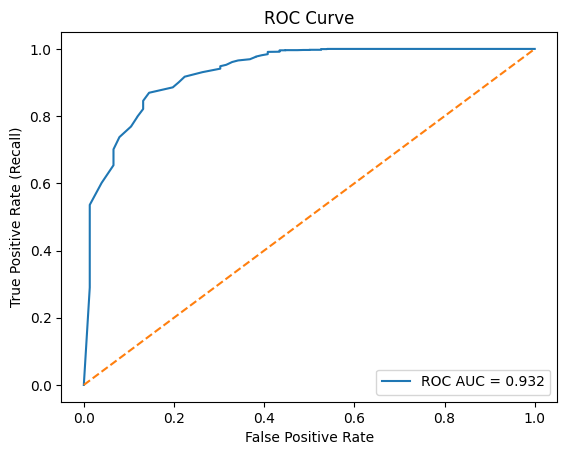

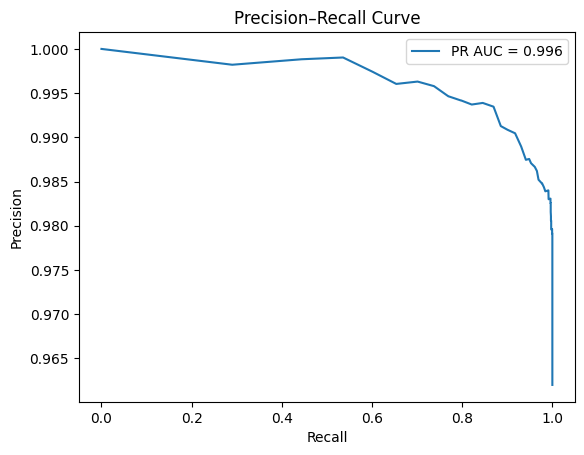

In [9]:


import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score, roc_auc_score



classes_ = best_model.named_steps["clf"].classes_
pos_label = classes_[np.argmax(classes_)]



fpr, tpr, thr = roc_curve(y_test, proba_test, pos_label=pos_label)
roc = auc(fpr, tpr)

prec, rec, thr_pr = precision_recall_curve(y_test, proba_test, pos_label=pos_label)
pr = average_precision_score(y_test, proba_test, pos_label=pos_label)

print(f"Using pos_label={pos_label}.  ROC AUC={roc:.3f} | PR AUC={pr:.3f}")

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(rec, prec, label=f"PR AUC = {pr:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()

### Threshold tuning (optimize F1 / Youden's J)

In [10]:


import numpy as np
from sklearn.metrics import (
    precision_recall_curve, roc_curve, confusion_matrix,
)


classes_ = best_model.named_steps["clf"].classes_
assert len(classes_) == 2, f"Expected binary classification, got classes={classes_}"
neg_label, pos_label = classes_[0], classes_[1]


prec, rec, thr_pr = precision_recall_curve(y_test, proba_test, pos_label=pos_label)
thr_pr = np.r_[0.0, thr_pr]
f1 = 2 * prec * rec / (prec + rec + 1e-12)
ix_f1 = int(np.nanargmax(f1))
thr_f1, f1_val = float(thr_pr[ix_f1]), float(f1[ix_f1])


fpr, tpr, thr_roc = roc_curve(y_test, proba_test, pos_label=pos_label)
J = tpr - fpr
ix_j = int(np.nanargmax(J))
thr_j, j_val = float(thr_roc[ix_j]), float(J[ix_j])

print(f"Best threshold by F1: {thr_f1:.4f} (F1={f1_val:.4f})")
print(f"Best threshold by Youden's J: {thr_j:.4f} (J={j_val:.4f})")

def preds_at(thr):

    return np.where(proba_test >= thr, pos_label, neg_label)

for name, thr in [("F1-opt", thr_f1), ("Youden-opt", thr_j)]:
    y_pred = preds_at(thr)
    cm = confusion_matrix(y_test, y_pred, labels=[neg_label, pos_label])
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    print(f"\n[{name}] thr={thr:.4f}  cm={cm.tolist()}  Precision={precision:.3f}  Recall={recall:.3f}")

Best threshold by F1: 0.4933 (F1=0.9895)
Best threshold by Youden's J: 0.9633 (J=0.7248)

[F1-opt] thr=0.4933  cm=[[34, 42], [0, 1924]]  Precision=0.979  Recall=1.000

[Youden-opt] thr=0.9633  cm=[[65, 11], [251, 1673]]  Precision=0.993  Recall=0.870


## 7) Probability calibration

Brier (uncalibrated): 0.01941020359122384
Brier (calibrated): 0.01843840649622418


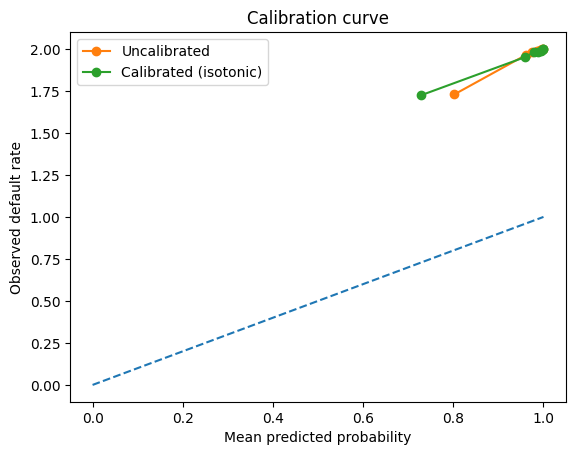

In [11]:


base = models[best_name]
cal = Pipeline([("prep", preprocessor), ("cal", CalibratedClassifierCV(base.steps[-1][1], method="isotonic", cv=3))])


cal.fit(X_train, y_train)
proba_cal = cal.predict_proba(X_test)[:,1]

def calibration_curve_points(y_true, proba, n_bins=10):
    bins = pd.qcut(proba, q=n_bins, duplicates="drop")
    dfc = pd.DataFrame({"y":y_true, "p":proba, "bin":bins})
    grouped = dfc.groupby("bin").agg(obs_rate=("y","mean"), pred=("p","mean"), count=("y","count")).reset_index()
    return grouped

unc = calibration_curve_points(y_test, proba_test)
iso = calibration_curve_points(y_test, proba_cal)

print("Brier (uncalibrated):", brier_score_loss(y_test, proba_test))
print("Brier (calibrated):", brier_score_loss(y_test, proba_cal))

plt.figure()
plt.plot([0,1],[0,1],'--')
plt.plot(unc["pred"], unc["obs_rate"], marker="o", label="Uncalibrated")
plt.plot(iso["pred"], iso["obs_rate"], marker="o", label="Calibrated (isotonic)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed default rate")
plt.title("Calibration curve")
plt.legend()
plt.show()


## 8) Feature importance / interpretability

num__action_taken                                               0.039360
num__ffiec_msa_md_median_family_income                          0.033116
num__tract_minority_population_percent                          0.032028
num__tract_owner_occupied_units                                 0.031866
num__tract_one_to_four_family_homes                             0.030009
num__tract_population                                           0.029534
num__tract_median_age_of_housing_units                          0.029009
num__tract_to_msa_income_percentage                             0.028749
num__derived_msa_md                                             0.028113
num__loan_purpose                                               0.027353
num__applicant_credit_score_type                                0.020559
num__loan_amount                                                0.017373
num__county_code                                                0.017139
cat__state_code_TX                                 

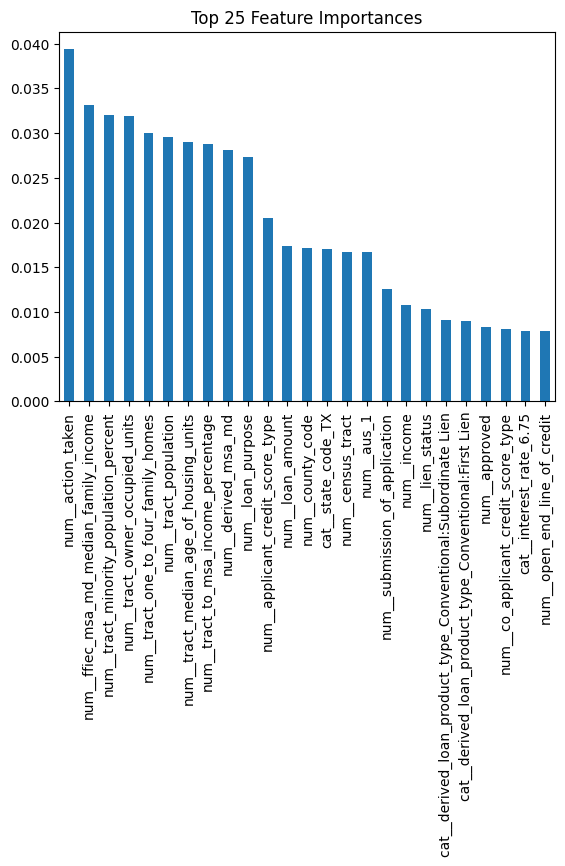

In [12]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


best_model.fit(X_train, y_train)

prep = best_model.named_steps["prep"]
clf  = best_model.named_steps["clf"]

def get_fitted_feature_names(prep, X_sample=None):


    if hasattr(prep, "get_feature_names_out"):
        try:
            return prep.get_feature_names_out().tolist()
        except Exception:
            pass


    names = []
    for name, trans, cols in prep.transformers_:
        if name == "remainder":
            continue


        if hasattr(trans, "named_steps"):

            ohe = trans.named_steps.get("ohe", None)
            if ohe is not None and hasattr(ohe, "categories_"):

                for col, cat_list in zip(cols, ohe.categories_):
                    names.extend([f"{col}={cat}" for cat in cat_list])
                continue


            names.extend(cols if isinstance(cols, list) else [cols])
        else:

            names.extend(cols if isinstance(cols, list) else [cols])

    return names


feature_names = get_fitted_feature_names(prep)



if X_train.shape[0] > 0:
    Xt_sample = prep.transform(X_train.iloc[:1])
else:
    Xt_sample = prep.transform(X_test.iloc[:1])

n_transformed = Xt_sample.shape[1]


if len(feature_names) != n_transformed:
    if len(feature_names) > n_transformed:
        feature_names = feature_names[:n_transformed]
    else:
        feature_names = feature_names + [f"feat_{i}" for i in range(len(feature_names), n_transformed)]


if hasattr(clf, "feature_importances_"):
    importances = pd.Series(clf.feature_importances_, index=feature_names)
    topk = importances.sort_values(ascending=False).head(25)
    display(topk)
    topk.plot(kind="bar")
    plt.title("Top 25 Feature Importances")
    plt.tight_layout()
    plt.show()

elif hasattr(clf, "coef_"):

    coefs = pd.Series(clf.coef_.ravel(), index=feature_names)
    topk = coefs.reindex(coefs.abs().sort_values(ascending=False).head(25).index)
    display(topk)
    topk.plot(kind="bar")
    plt.title("Top 25 Coefficients (absolute magnitude)")
    plt.tight_layout()
    plt.show()

else:
    print("This model does not expose feature_importances_ or coef_. Consider using permutation importance.")

## 9) Group fairness checks (if attributes present)

In [13]:


candidates = [c for c in CANDIDATE_SENSITIVE if c in df.columns]
print("Detected sensitive attribute columns:", candidates)

def group_metrics(y_true, proba, sensitive):
    m = []
    for g, idx in pd.Series(sensitive).groupby(sensitive).groups.items():
        gt = y_true.iloc[list(idx)]
        pr = proba[list(idx)]
        pred = (pr >= 0.5).astype(int)
        rec = ( (gt==1) & (pred==1) ).sum() / max((gt==1).sum(), 1)
        fpr = ( (gt==0) & (pred==1) ).sum() / max((gt==0).sum(), 1)
        pos_rate = pred.mean()
        m.append({"group": g, "size": len(idx), "TPR": rec, "FPR": fpr, "PosRate": pos_rate})
    return pd.DataFrame(m).sort_values("group")

for col in candidates:

    s_col = X_test[col] if col in X_test.columns else df.loc[X_test.index, col]
    gm = group_metrics(y_test, proba_test, s_col)
    display(pd.DataFrame({"metric":"TPR disparity vs max", "value":[gm["TPR"].max() - gm["TPR"].min()]}))
    display(pd.DataFrame({"metric":"PosRate disparity vs max", "value":[gm["PosRate"].max() - gm["PosRate"].min()]}))
    display(gm)


Detected sensitive attribute columns: []
